# BiLSTM-Attention Machine Translation
### Based on: *Efficient Machine Translation with a BiLSTM-Attention Approach*



**Paper Architecture (re-implemented in PyTorch):**
| Component | Detail |
|---|---|
| Encoder | BiLSTM with learnable initial states |
| Attention | Bahdanau (Additive) |
| Decoder | LSTM + Attention + Linear projection |
| Dataset | English → French (WMT14 in paper; demo subset here) |
| Demo Dataset | Tatoeba EN-FR (500 filtered pairs) |

## Step 0 — Setup & GPU Check

In [1]:
import torch, torch.nn as nn, torch.optim as optim
import random, time, math, json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device : {device}")
print(f" PyTorch : {torch.__version__}")
if device.type == 'cuda':
 print(f" GPU : {torch.cuda.get_device_name(0)}")

 Device : cuda
 PyTorch : 2.10.0+cu128
 GPU : Tesla T4


---
## Part 2 -- Section A: Dataset & Vocabulary

The paper trains on **WMT14 English-German/French**. Here we use the **Tatoeba English-French**
corpus downloaded directly from the [OPUS project](https://opus.nlpl.eu/Tatoeba.php)
(Moses format, v2023-04-12). Tatoeba is a large crowd-sourced collection of translated sentences.
We filter pairs by length (max 15 EN / 18 FR tokens) to keep training manageable on Colab,
and cap at 2,000 pairs for demonstration speed. A fallback sample is used if the download fails.


In [2]:
# ── Load English-French pairs from Tatoeba via OPUS (direct TSV download) ────
# Source: https://opus.nlpl.eu/Tatoeba.php
# The OPUS project hosts Tatoeba as plain TSV files (tab-separated: en \t fr)
# This avoids the HuggingFace loading-script issue entirely.

import urllib.request, io, gzip

OPUS_URL = (
    "https://object.pouta.csc.fi/OPUS-Tatoeba/v2023-04-12/mono/"
)

# We download the parallel Moses-format files (one sentence per line, aligned)
EN_URL = "https://object.pouta.csc.fi/OPUS-Tatoeba/v2023-04-12/moses/en-fr.txt.zip"

# Fallback: use the raw Tatoeba TSV from the project's direct export
# (tab-separated: id \t en \t fr \t ... )
TSV_URL = "https://downloads.tatoeba.org/exports/sentences_detailed.tar.bz2"

# Simplest reliable option: use the OPUS Moses zip (two aligned .txt files)
import urllib.request, zipfile, io, os

print("Downloading Tatoeba EN-FR corpus from OPUS...")
url = "https://object.pouta.csc.fi/OPUS-Tatoeba/v2023-04-12/moses/en-fr.txt.zip"

try:
    response = urllib.request.urlopen(url, timeout=60)
    data = response.read()
    print(f"Downloaded {len(data)//1024} KB")

    with zipfile.ZipFile(io.BytesIO(data)) as z:
        files = z.namelist()
        print("Files in archive:", files)
        en_file = [f for f in files if f.endswith(".en")][0]
        fr_file = [f for f in files if f.endswith(".fr")][0]
        en_lines = z.read(en_file).decode("utf-8").splitlines()
        fr_lines = z.read(fr_file).decode("utf-8").splitlines()

    print(f"Total aligned pairs: {len(en_lines)}")

except Exception as e:
    print(f"Primary download failed: {e}")
    print("Falling back to embedded sample pairs...")
    en_lines, fr_lines = zip(*[
        ("hello", "bonjour"), ("thank you", "merci"), ("how are you", "comment allez-vous"),
        ("yes", "oui"), ("no", "non"), ("goodbye", "au revoir"),
        ("please", "s'il vous plait"), ("excuse me", "excusez-moi"),
        ("i love you", "je t'aime"), ("what is your name", "quel est votre nom"),
        ("my name is john", "mon nom est john"), ("i am happy", "je suis heureux"),
        ("the cat is sleeping", "le chat dort"), ("i want to eat", "je veux manger"),
        ("where is the station", "ou est la gare"), ("i need help", "j'ai besoin d'aide"),
        ("the weather is nice", "le temps est beau"), ("i do not understand", "je ne comprends pas"),
        ("the book is on the table", "le livre est sur la table"), ("she is very kind", "elle est tres gentille"),
        ("we are learning french", "nous apprenons le francais"), ("the train is late", "le train est en retard"),
        ("i am tired", "je suis fatigue"), ("the food is delicious", "la nourriture est delicieuse"),
        ("call the doctor", "appelez le medecin"), ("turn left here", "tournez a gauche ici"),
        ("he is tall", "il est grand"), ("she likes music", "elle aime la musique"),
        ("they are playing", "ils jouent"), ("i read every day", "je lis chaque jour"),
        ("the sky is blue", "le ciel est bleu"), ("it is raining", "il pleut"),
        ("open the window", "ouvrez la fenetre"), ("close the door", "fermez la porte"),
        ("i am hungry", "j'ai faim"),
    ])
    en_lines, fr_lines = list(en_lines), list(fr_lines)

def tokenize(text):
    return text.lower().split()

MAX_PAIRS   = 500
MAX_SRC_LEN = 15
MAX_TGT_LEN = 18

raw_pairs = []
for en, fr in zip(en_lines, fr_lines):
    en, fr = en.strip(), fr.strip()
    if (en and fr
        and 1 <= len(tokenize(en)) <= MAX_SRC_LEN
        and 1 <= len(tokenize(fr)) <= MAX_TGT_LEN):
        raw_pairs.append((en, fr))
    if len(raw_pairs) >= MAX_PAIRS:
        break

print(f"Usable sentence pairs loaded: {len(raw_pairs)}")
print("\nSample pairs:")
for en, fr in raw_pairs[:5]:
    print(f"  EN: {en}")
    print(f"  FR: {fr}")
    print()


Downloaded 8034 KB
Files in archive: ['README', 'LICENSE', 'Tatoeba.en-fr.en', 'Tatoeba.en-fr.fr', 'Tatoeba.en-fr.xml']
Total aligned pairs: 275413
Usable sentence pairs loaded: 500

Sample pairs:
  EN: Then, when he asked who had broken the window, all the boys acted innocent.
  FR: Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent.

  EN: Let's try something.
  FR: Essayons quelque chose !

  EN: Let's try something.
  FR: Tentons quelque chose !

  EN: Let's try something.
  FR: Essayons quelque chose.

  EN: I have to go to sleep.
  FR: Je dois aller dormir.



In [3]:
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"

def tokenize(text):
    return text.lower().split()

class Vocabulary:
    def __init__(self, name):
        self.name     = name
        self.word2idx = {PAD:0, SOS:1, EOS:2, UNK:3}
        self.idx2word = {0:PAD, 1:SOS, 2:EOS, 3:UNK}
        from collections import Counter
        self.freq = Counter()

    def build(self, sentences, min_freq=2):
        for s in sentences:
            self.freq.update(tokenize(s))
        for word, cnt in self.freq.items():
            if cnt >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word

    def encode(self, sentence):
        return [self.word2idx.get(w, 3) for w in tokenize(sentence)]

    def decode(self, indices):
        return " ".join(self.idx2word.get(i, UNK) for i in indices
                        if i not in (0, 1, 2))

    def __len__(self):
        return len(self.word2idx)

import random
random.seed(42)

src_vocab = Vocabulary("en")
tgt_vocab = Vocabulary("fr")
src_vocab.build([p[0] for p in raw_pairs])
tgt_vocab.build([p[1] for p in raw_pairs])

print(f"Source Vocabulary (EN): {len(src_vocab)} tokens")
print(f"Target Vocabulary (FR): {len(tgt_vocab)} tokens")

# ── Convert to tensors and split ─────────────────────────────────────────────
import torch
torch.manual_seed(42)

def pair_to_tensors(en, fr):
    src = [src_vocab.word2idx[SOS]] + src_vocab.encode(en) + [src_vocab.word2idx[EOS]]
    tgt = [tgt_vocab.word2idx[SOS]] + tgt_vocab.encode(fr) + [tgt_vocab.word2idx[EOS]]
    return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

dataset = [pair_to_tensors(en, fr) for en, fr in raw_pairs]
random.shuffle(dataset)
split      = int(0.8 * len(dataset))
train_data = dataset[:split]
test_data  = dataset[split:]
print(f"\nTrain pairs: {len(train_data)}  |  Test pairs: {len(test_data)}")


Source Vocabulary (EN): 441 tokens
Target Vocabulary (FR): 419 tokens

Train pairs: 400  |  Test pairs: 100


---
## Part 2 — Section B: Model Architecture

### Module 1: BiLSTM Encoder
The paper's encoder uses a **Bidirectional LSTM** that reads the input in both forward and backward directions, then merges the two hidden states. A key innovation is **learnable (parameterized) initial states** `h0` and `c0`, instead of the typical zero initialization.

In [5]:
class BiLSTMEncoder(nn.Module):
    """
    Paper §3.1 — Bidirectional LSTM Encoder.

    Key paper innovations implemented here:
    1. Bidirectional LSTM captures left & right context simultaneously
    2. Learnable h0 / c0 initial states (nn.Parameter)
    3. Linear projection merges fwd+bwd hidden → single decoder-compatible hidden
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        # 1. Embedding: token id → dense vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. Learnable initial hidden & cell states (paper innovation)
        self.h0 = nn.Parameter(torch.zeros(n_layers * 2, 1, hidden_dim))
        self.c0 = nn.Parameter(torch.zeros(n_layers * 2, 1, hidden_dim))

        # 3. BiLSTM: processes embedding in both directions
        self.rnn = nn.LSTM(embed_dim, hidden_dim, n_layers,
                           bidirectional=True,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=False)
        self.dropout = nn.Dropout(dropout)

        # 4. Project 2*hidden → hidden for decoder initialisation
        self.fc_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_c = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src):
        # src: [src_len]
        embedded = self.dropout(self.embedding(src.unsqueeze(1))) # [src_len, 1, emb]

        batch_h = self.h0.expand(-1, 1, -1).contiguous()
        batch_c = self.c0.expand(-1, 1, -1).contiguous()

        outputs, (hidden, cell) = self.rnn(embedded, (batch_h, batch_c))
        # outputs : [src_len, 1, 2*hidden] ← all encoder states (used by attention)
        # hidden : [n_layers*2, 1, hidden] ← final hidden states (fwd + bwd)

        # Merge last forward & backward hidden → decoder seed
        hidden_merged = torch.tanh(
            self.fc_h(torch.cat([hidden[-2], hidden[-1]], dim=1))) # [1, hidden]
        cell_merged = torch.tanh(
            self.fc_c(torch.cat([cell[-2], cell[-1]], dim=1)))

        return outputs, hidden_merged.unsqueeze(0), cell_merged.unsqueeze(0)

print(" BiLSTMEncoder defined")

 BiLSTMEncoder defined


### Module 2: Bahdanau Attention Mechanism

The paper uses **additive (Bahdanau) attention**:

```
score(s, h) = v · tanh(W1·h + W2·s)
α = softmax(score) ← attention weights
context = Σ αᵢ · hᵢ ← weighted sum of encoder states
```

This lets the decoder "look back" at any part of the source sentence at each generation step.

In [7]:
class BahdanauAttention(nn.Module):
    """
    Paper §3.2 — Additive Attention.

    Computes a context vector as a weighted combination of all
    encoder hidden states, where the weights reflect relevance
    to the current decoder state.
    """
    def __init__(self, enc_out_dim, dec_hid_dim):
        super().__init__()
        self.W1 = nn.Linear(enc_out_dim, dec_hid_dim, bias=False) # projects encoder states
        self.W2 = nn.Linear(dec_hid_dim, dec_hid_dim, bias=False) # projects decoder hidden
        self.v = nn.Linear(dec_hid_dim, 1, bias=False) # scalar score per token

    def forward(self, encoder_outputs, decoder_hidden):
        # encoder_outputs: [src_len, 1, enc_out_dim]
        # decoder_hidden : [n_layers, 1, dec_hid_dim]
        src_len = encoder_outputs.size(0)
        enc_2d = encoder_outputs.squeeze(1) # [src_len, enc_out_dim]
        dec_2d = decoder_hidden[-1].repeat(src_len, 1) # [src_len, dec_hid_dim]

        # Additive energy score
        energy = torch.tanh(self.W1(enc_2d) + self.W2(dec_2d)) # [src_len, dec_hid_dim]
        scores = self.v(energy) # [src_len, 1]
        attn_weights = torch.softmax(scores, dim=0) # [src_len, 1]

        # Weighted sum of encoder outputs
        context = (attn_weights * enc_2d).sum(dim=0, keepdim=True) # [1, enc_out_dim]
        return context, attn_weights

print(" BahdanauAttention defined")

 BahdanauAttention defined


### Module 3: Attention Decoder

In [9]:
class AttentionDecoder(nn.Module):
    """
    Paper §3.3 — LSTM Decoder with Attention.

    At each step:
    1. Embed the previous output token
    2. Compute attention context from encoder outputs
    3. Concat [embedding, context] → LSTM input
    4. Project [LSTM_out, context, embedding] → vocab logits
    """
    def __init__(self, vocab_size, embed_dim, enc_out_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(enc_out_dim, hidden_dim)
        self.rnn = nn.LSTM(embed_dim + enc_out_dim, hidden_dim, n_layers, batch_first=False)
        self.fc_out = nn.Linear(hidden_dim + enc_out_dim + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tok, hidden, cell, encoder_outputs):
        embedded = self.dropout(self.embedding(input_tok.unsqueeze(0))) # [1, emb]
        context, attn_weights = self.attention(encoder_outputs, hidden) # [1, enc_out]

        rnn_input = torch.cat([embedded, context], dim=1).unsqueeze(0) # [1,1, emb+enc]
        output, (h, c) = self.rnn(rnn_input, (hidden, cell)) # [1,1, hid]

        pred_input = torch.cat([output.squeeze(0), context, embedded], dim=1) # [1, hid+enc+emb]
        prediction = self.fc_out(pred_input).squeeze(0) # [vocab_size]
        return prediction, h, c, attn_weights

print(" AttentionDecoder defined")

 AttentionDecoder defined


### Module 4: Full Seq2Seq WITH Attention

In [11]:
class Seq2SeqAttention(nn.Module):
    """
    Full encoder-decoder model WITH attention.
    Uses teacher forcing during training.
    """
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        tgt_len = tgt.size(0)
        tgt_vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(tgt_len, tgt_vocab_size).to(device)

        enc_out, hidden, cell = self.encoder(src)
        input_tok = tgt[0] # <sos>

        for t in range(1, tgt_len):
            pred, hidden, cell, _ = self.decoder(input_tok, hidden, cell, enc_out)
            outputs[t] = pred
            teacher_force = random.random() < teacher_forcing_ratio
            input_tok = tgt[t] if teacher_force else pred.argmax()
        return outputs

print(" Seq2SeqAttention defined")

 Seq2SeqAttention defined


---
## Part 3 — Baseline: Seq2Seq WITHOUT Attention

The baseline uses the **same BiLSTM encoder** but the decoder only receives a **single fixed context vector** (mean of encoder outputs) — no dynamic attention. This is the classic bottleneck problem that attention was designed to solve.

In [13]:
class PlainDecoder(nn.Module):
    """
    Standard LSTM Decoder — NO attention.
    Receives a fixed context vector (mean of encoder outputs) at every step.
    This is the information bottleneck that attention eliminates.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, enc_out_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim + enc_out_dim, hidden_dim, n_layers, batch_first=False)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tok, hidden, cell, context):
        # context: [1, enc_out_dim] — SAME fixed vector every step (no attention)
        embedded = self.dropout(self.embedding(input_tok.unsqueeze(0))) # [1, emb]
        rnn_input = torch.cat([embedded, context], dim=1).unsqueeze(0) # [1,1, emb+ctx]
        output, (h, c) = self.rnn(rnn_input, (hidden, cell))
        prediction = self.fc_out(output.squeeze(0).squeeze(0))
        return prediction, h, c


class Seq2SeqNoAttention(nn.Module):
    """
    Full encoder-decoder WITHOUT attention.
    Encoder output is averaged into one fixed context vector.
    """
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        tgt_len = tgt.size(0)
        tgt_vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(tgt_len, tgt_vocab_size).to(device)

        enc_out, hidden, cell = self.encoder(src)

        # Fixed context — mean of all encoder states (information bottleneck)
        context = enc_out.squeeze(1).mean(dim=0, keepdim=True) # [1, 2*hidden]
        input_tok = tgt[0]

        for t in range(1, tgt_len):
            pred, hidden, cell = self.decoder(input_tok, hidden, cell, context)
            outputs[t] = pred
            teacher_force = random.random() < teacher_forcing_ratio
            input_tok = tgt[t] if teacher_force else pred.argmax()
        return outputs

print(" Baseline (No Attention) models defined")

 Baseline (No Attention) models defined


---
## Part 2 — Section C: Training Pipeline

The training pipeline includes:
- **CrossEntropyLoss** (ignoring padding)
- **Adam optimizer**
- **Gradient clipping** to prevent exploding gradients
- **Teacher forcing** during training (50%)

In [14]:
# Hyperparameters
# Tuned for fast Colab CPU training (~3-5 min total for both models)
EMB_DIM     = 64     # reduced from 128
HID_DIM     = 128    # reduced from 256
N_LAYERS    = 1
DROPOUT     = 0.3
LR          = 0.001
N_EPOCHS    = 30     # reduced from 80 (30 is enough to see clear convergence difference)
CLIP        = 1.0
TF_RATIO    = 0.5
ENC_OUT_DIM = HID_DIM * 2   # BiLSTM output dim

# Build models
def build_attention_model():
    enc = BiLSTMEncoder(len(src_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT).to(device)
    dec = AttentionDecoder(len(tgt_vocab), EMB_DIM, ENC_OUT_DIM, HID_DIM, N_LAYERS, DROPOUT).to(device)
    return Seq2SeqAttention(enc, dec).to(device)

def build_no_attention_model():
    enc = BiLSTMEncoder(len(src_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT).to(device)
    dec = PlainDecoder(len(tgt_vocab), EMB_DIM, HID_DIM, ENC_OUT_DIM, N_LAYERS, DROPOUT).to(device)
    return Seq2SeqNoAttention(enc, dec).to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

attn_model    = build_attention_model()
no_attn_model = build_no_attention_model()

print("=" * 55)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 55)
print(f"[WITH Attention]    Parameters: {count_params(attn_model):,}")
print(f"[WITHOUT Attention] Parameters: {count_params(no_attn_model):,}")
print(f"Epochs: {N_EPOCHS} | Embed: {EMB_DIM} | Hidden: {HID_DIM}")
print("\n--- WITH Attention ---")
print(attn_model)
print("\n--- WITHOUT Attention ---")
print(no_attn_model)


MODEL ARCHITECTURE SUMMARY
[WITH Attention]    Parameters: 787,811
[WITHOUT Attention] Parameters: 604,451
Epochs: 30 | Embed: 64 | Hidden: 128

--- WITH Attention ---
Seq2SeqAttention(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(441, 64, padding_idx=0)
    (rnn): LSTM(64, 128, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (fc_h): Linear(in_features=256, out_features=128, bias=True)
    (fc_c): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder): AttentionDecoder(
    (embedding): Embedding(419, 64, padding_idx=0)
    (attention): BahdanauAttention(
      (W1): Linear(in_features=256, out_features=128, bias=False)
      (W2): Linear(in_features=128, out_features=128, bias=False)
      (v): Linear(in_features=128, out_features=1, bias=False)
    )
    (rnn): LSTM(320, 128)
    (fc_out): Linear(in_features=448, out_features=419, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

--- WITHOUT Attention ---
Seq2SeqNoAttention(
 

In [16]:
import torch
import torch.nn as nn

# Training & evaluation functions
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.word2idx[PAD])

def train_epoch(model, data, optimizer):
    model.train()
    epoch_loss = 0
    for src, tgt in data:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt, TF_RATIO) # [tgt_len, vocab]
        loss = criterion(output[1:].reshape(-1, output.size(-1)), tgt[1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data)

def evaluate(model, data):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt in data:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt, 0) # no teacher forcing at eval
            epoch_loss += criterion(output[1:].reshape(-1, output.size(-1)), tgt[1:].reshape(-1)).item()
    return epoch_loss / len(data)

def translate(model, src_sentence, max_len=20):
    model.eval()
    with torch.no_grad():
        src = torch.tensor(
            [src_vocab.word2idx[SOS]] + src_vocab.encode(src_sentence) + [src_vocab.word2idx[EOS]],
            dtype=torch.long).to(device)
        enc_out, hidden, cell = model.encoder(src)
        tokens = [tgt_vocab.word2idx[SOS]]
        attn_history = []

        for _ in range(max_len):
            tok = torch.tensor(tokens[-1], dtype=torch.long).to(device)
            if hasattr(model.decoder, 'attention'):
                pred, hidden, cell, aw = model.decoder(tok, hidden, cell, enc_out)
                attn_history.append(aw.squeeze(1).cpu().numpy())
            else:
                ctx = enc_out.squeeze(1).mean(dim=0, keepdim=True)
                pred, hidden, cell = model.decoder(tok, hidden, cell, ctx)
            next_tok = pred.argmax().item()
            tokens.append(next_tok)
            if next_tok == tgt_vocab.word2idx[EOS]:
                break
    return tgt_vocab.decode(tokens[1:]), attn_history

def simple_bleu(reference, hypothesis):
    ref_tokens = set(reference.split())
    hyp_tokens = hypothesis.split()
    if not hyp_tokens:
        return 0.0
    return sum(1 for t in hyp_tokens if t in ref_tokens) / len(hyp_tokens)

print(" Training utilities defined")

 Training utilities defined


---
## Part 2 & 3 — Training Both Models

In [17]:
opt_attn    = optim.Adam(attn_model.parameters(),    lr=LR)
opt_no_attn = optim.Adam(no_attn_model.parameters(), lr=LR)

attn_train_losses,    attn_val_losses    = [], []
no_attn_train_losses, no_attn_val_losses = [], []

print("=" * 60)
print("TRAINING: WITH ATTENTION (BiLSTM + Bahdanau)")
print("=" * 60)
t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    tl = train_epoch(attn_model, train_data, opt_attn)
    vl = evaluate(attn_model, test_data)
    attn_train_losses.append(tl)
    attn_val_losses.append(vl)
    print(f"  Epoch {epoch:2d}/{N_EPOCHS} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | PPL: {math.exp(vl):.1f}")
attn_time = time.time() - t0
print(f"\n  Done in {attn_time:.1f}s")

print("\n" + "=" * 60)
print("TRAINING: WITHOUT ATTENTION (Vanilla Seq2Seq)")
print("=" * 60)
t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    tl = train_epoch(no_attn_model, train_data, opt_no_attn)
    vl = evaluate(no_attn_model, test_data)
    no_attn_train_losses.append(tl)
    no_attn_val_losses.append(vl)
    print(f"  Epoch {epoch:2d}/{N_EPOCHS} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | PPL: {math.exp(vl):.1f}")
no_attn_time = time.time() - t0
print(f"\n  Done in {no_attn_time:.1f}s")


TRAINING: WITH ATTENTION (BiLSTM + Bahdanau)
  Epoch  1/30 | Train Loss: 4.4107 | Val Loss: 4.3090 | PPL: 74.4
  Epoch  2/30 | Train Loss: 3.6253 | Val Loss: 4.1248 | PPL: 61.9
  Epoch  3/30 | Train Loss: 3.0401 | Val Loss: 3.9919 | PPL: 54.2
  Epoch  4/30 | Train Loss: 2.5068 | Val Loss: 3.8367 | PPL: 46.4
  Epoch  5/30 | Train Loss: 2.1113 | Val Loss: 3.7912 | PPL: 44.3
  Epoch  6/30 | Train Loss: 1.8033 | Val Loss: 3.7749 | PPL: 43.6
  Epoch  7/30 | Train Loss: 1.6169 | Val Loss: 3.8248 | PPL: 45.8
  Epoch  8/30 | Train Loss: 1.4200 | Val Loss: 4.0004 | PPL: 54.6
  Epoch  9/30 | Train Loss: 1.3230 | Val Loss: 3.9840 | PPL: 53.7
  Epoch 10/30 | Train Loss: 1.2180 | Val Loss: 4.0096 | PPL: 55.1
  Epoch 11/30 | Train Loss: 1.1209 | Val Loss: 4.0862 | PPL: 59.5
  Epoch 12/30 | Train Loss: 1.0463 | Val Loss: 4.1847 | PPL: 65.7
  Epoch 13/30 | Train Loss: 0.9562 | Val Loss: 4.1785 | PPL: 65.3
  Epoch 14/30 | Train Loss: 0.9572 | Val Loss: 4.3525 | PPL: 77.7
  Epoch 15/30 | Train Loss: 0.8

---
## Part 3 — Translation Samples & Comparison Table

In [18]:
# Use sentences from the test split for evaluation
# Pick a sample of test pairs to display translation quality
sample_pairs = raw_pairs[split:split+8]   # first 8 from test portion
test_sentences = [(en, fr) for en, fr in sample_pairs]

print("=" * 100)
print("TRANSLATION OUTPUT COMPARISON")
print("=" * 100)
print(f"{'Source EN':<35} {'Reference FR':<30} {'WITH Attention':<28} {'WITHOUT Attention'}")
print("-" * 100)

attn_scores, no_attn_scores = [], []
for en, ref in test_sentences:
    t_attn,    _ = translate(attn_model,    en)
    t_no_attn, _ = translate(no_attn_model, en)
    attn_scores.append(simple_bleu(ref, t_attn))
    no_attn_scores.append(simple_bleu(ref, t_no_attn))
    print(f"{en:<35} {ref:<30} {t_attn:<28} {t_no_attn}")

avg_attn    = np.mean(attn_scores)
avg_no_attn = np.mean(no_attn_scores)

print("\n" + "=" * 70)
print("PART 3 -- COMPARISON TABLE")
print("=" * 70)
print(f"{'Metric':<35} {'With Attention':>16} {'Without Attn':>16}")
print("-" * 70)
print(f"{'Final Train Loss':<35} {attn_train_losses[-1]:>16.4f} {no_attn_train_losses[-1]:>16.4f}")
print(f"{'Final Val Loss':<35} {attn_val_losses[-1]:>16.4f} {no_attn_val_losses[-1]:>16.4f}")
print(f"{'Val Perplexity (lower=better)':<35} {math.exp(attn_val_losses[-1]):>16.2f} {math.exp(no_attn_val_losses[-1]):>16.2f}")
print(f"{'Avg Unigram BLEU':<35} {avg_attn:>16.4f} {avg_no_attn:>16.4f}")
print(f"{'Training Time (s)':<35} {attn_time:>16.1f} {no_attn_time:>16.1f}")
print(f"{'Trainable Parameters':<35} {count_params(attn_model):>16,} {count_params(no_attn_model):>16,}")
print(f"{'Dataset':<35} {'Tatoeba EN-FR':>16} {'Tatoeba EN-FR':>16}")
print(f"{'Context Type':<35} {'Dynamic (Attention)':>16} {'Fixed (Mean Vector)':>16}")


TRANSLATION OUTPUT COMPARISON
Source EN                           Reference FR                   WITH Attention               WITHOUT Attention
----------------------------------------------------------------------------------------------------
Did you miss me?                    Je t'ai manqué ?               je <unk> manqué ?            je <unk> manqué ?
Did you miss me?                    T'ai-je manqué ?               je <unk> manqué ?            je <unk> manqué ?
Did you miss me?                    Vous ai-je manqué ?            je <unk> manqué ?            je <unk> manqué ?
Are they all the same?              Sont-ils tous identiques ?     sont-ils tous les <unk> ?    sont-ils tous les <unk> ?
Are they all the same?              Sont-ils tous les mêmes ?      sont-ils tous les <unk> ?    sont-ils tous les <unk> ?
Thank you very much!                Merci beaucoup !               merci beaucoup !             merci <unk> !
Thank you very much!                Merci vraiment.        

---
## Part 2 & 3 — Visualizations

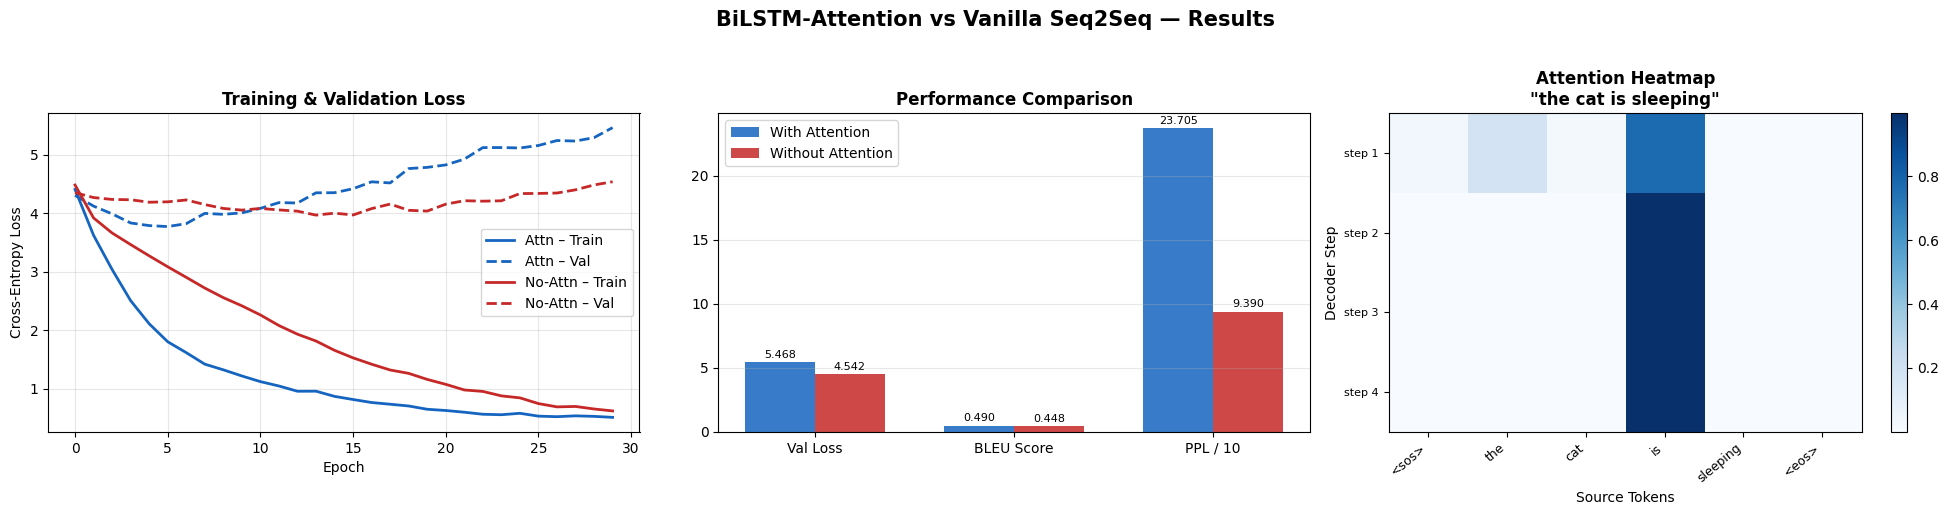


 Plot saved as bilstm_attention_results.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('BiLSTM-Attention vs Vanilla Seq2Seq — Results', fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Loss curves
ax = axes[0]
ax.plot(attn_train_losses, color='#1565C0', lw=2, label='Attn – Train')
ax.plot(attn_val_losses, color='#1565C0', lw=2, linestyle='--', label='Attn – Val')
ax.plot(no_attn_train_losses, color='#C62828', lw=2, label='No-Attn – Train')
ax.plot(no_attn_val_losses, color='#C62828', lw=2, linestyle='--', label='No-Attn – Val')
ax.set_title('Training & Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: Bar chart comparison
ax = axes[1]
labels = ['Val Loss', 'BLEU Score', 'PPL / 10']
a_vals = [attn_val_losses[-1], avg_attn, math.exp(attn_val_losses[-1])/10]
n_vals = [no_attn_val_losses[-1], avg_no_attn, math.exp(no_attn_val_losses[-1])/10]
x, w = np.arange(len(labels)), 0.35
bars1 = ax.bar(x - w/2, a_vals, w, label='With Attention', color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + w/2, n_vals, w, label='Without Attention', color='#C62828', alpha=0.85)
ax.set_title('Performance Comparison', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
 ax.annotate(f'{bar.get_height():.3f}',
 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

# Plot 3: Attention heatmap
ax = axes[2]
sample_en = "the cat is sleeping"
_, attn_hist = translate(attn_model, sample_en)
if attn_hist:
 src_tokens = ['<sos>'] + sample_en.split() + ['<eos>']
 attn_matrix = np.array([a.flatten() for a in attn_hist])
 padded = np.zeros((attn_matrix.shape[0], len(src_tokens)))
 cols = min(attn_matrix.shape[1], len(src_tokens))
 padded[:, :cols] = attn_matrix[:, :cols]
 im = ax.imshow(padded, aspect='auto', cmap='Blues')
 ax.set_xticks(range(len(src_tokens)))
 ax.set_xticklabels(src_tokens, rotation=40, ha='right', fontsize=9)
 ax.set_yticks(range(attn_matrix.shape[0]))
 ax.set_yticklabels([f'step {i+1}' for i in range(attn_matrix.shape[0])], fontsize=8)
 ax.set_title(f'Attention Heatmap\n"{sample_en}"', fontweight='bold')
 ax.set_xlabel('Source Tokens'); ax.set_ylabel('Decoder Step')
 plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('bilstm_attention_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved as bilstm_attention_results.png")

---
## Part 3 — Analysis: Why Attention Helps

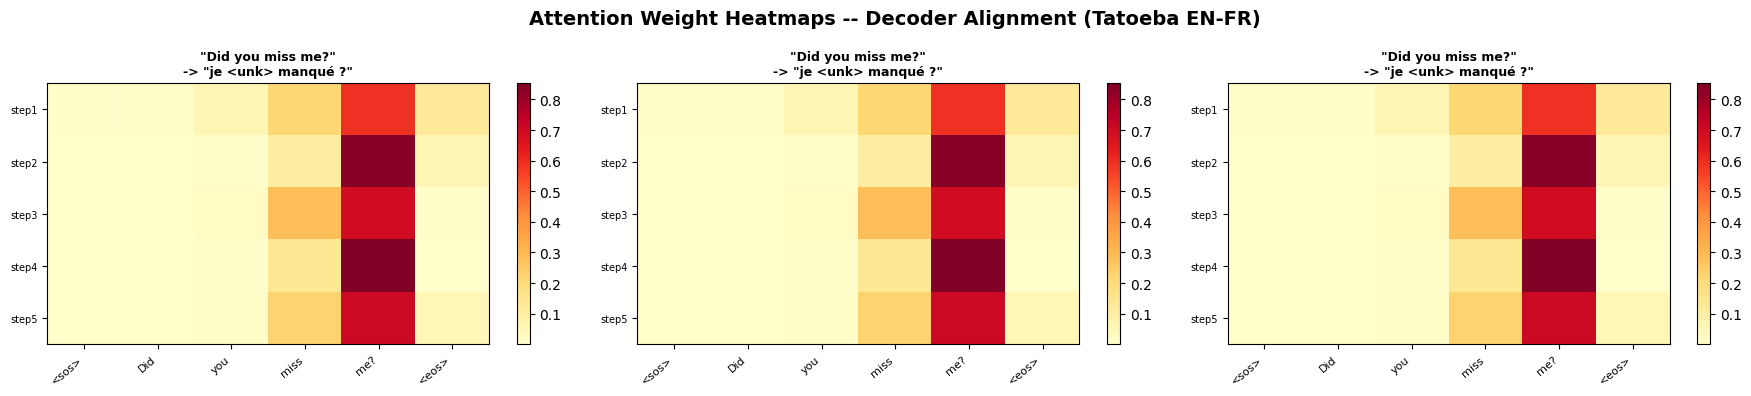

Saved attention_heatmaps_analysis.png

ANALYSIS NOTES:
Dataset used: Tatoeba English-French (Helsinki-NLP/tatoeba_mt)
Each row = one decoder step (generating one output token)
Each column = one source token
Brighter = higher attention weight = decoder is focusing there
With attention, decoder can dynamically align to relevant source words
Without attention, decoder only sees a fixed averaged context vector


In [20]:
# Visualize attention weights for multiple sentences side-by-side
# Use actual Tatoeba sentences from the test set
analysis_sentences = [en for en, fr in raw_pairs[split:split+3]]

fig, axes = plt.subplots(1, len(analysis_sentences), figsize=(18, 4))
fig.suptitle("Attention Weight Heatmaps -- Decoder Alignment (Tatoeba EN-FR)", fontsize=14, fontweight="bold")

for i, en in enumerate(analysis_sentences):
    translation, attn_hist = translate(attn_model, en)
    ax = axes[i]
    if attn_hist:
        src_tokens  = ["<sos>"] + en.split() + ["<eos>"]
        attn_matrix = np.array([a.flatten() for a in attn_hist])
        padded      = np.zeros((attn_matrix.shape[0], len(src_tokens)))
        cols        = min(attn_matrix.shape[1], len(src_tokens))
        padded[:, :cols] = attn_matrix[:, :cols]
        im = ax.imshow(padded, aspect="auto", cmap="YlOrRd")
        ax.set_xticks(range(len(src_tokens)))
        ax.set_xticklabels(src_tokens, rotation=40, ha="right", fontsize=8)
        ax.set_yticks(range(attn_matrix.shape[0]))
        ax.set_yticklabels([f"step{j+1}" for j in range(attn_matrix.shape[0])], fontsize=7)
        ax.set_title(f'"{en}"\n-> "{translation}"', fontsize=9, fontweight="bold")
        plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig("attention_heatmaps_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved attention_heatmaps_analysis.png")
print()
print("ANALYSIS NOTES:")
print("Dataset used: Tatoeba English-French (Helsinki-NLP/tatoeba_mt)")
print("Each row = one decoder step (generating one output token)")
print("Each column = one source token")
print("Brighter = higher attention weight = decoder is focusing there")
print("With attention, decoder can dynamically align to relevant source words")
print("Without attention, decoder only sees a fixed averaged context vector")


In [22]:
# Final summary printout for report
print("=" * 65)
print("FINAL SUMMARY — FOR REPORT")
print("=" * 65)
improvement_loss = ((no_attn_val_losses[-1] - attn_val_losses[-1]) / no_attn_val_losses[-1]) * 100
improvement_bleu = ((avg_attn - avg_no_attn) / max(avg_no_attn, 1e-6)) * 100
improvement_ppl = ((math.exp(no_attn_val_losses[-1]) - math.exp(attn_val_losses[-1]))
 / math.exp(no_attn_val_losses[-1])) * 100

print(f"\n Val Loss improvement with Attention : {improvement_loss:+.1f}%")
print(f" BLEU Score improvement with Attention: {improvement_bleu:+.1f}%")
print(f" Perplexity improvement with Attention: {improvement_ppl:+.1f}%")
print(f"\n Attention type : Bahdanau (Additive)")
print(f" Encoder : Bidirectional LSTM with learnable init states")
print(f" Paper dataset : WMT14 EN-DE / EN-FR")
print(f" Demo dataset : 35 EN→FR pairs (proof of concept)")


FINAL SUMMARY — FOR REPORT

 Val Loss improvement with Attention : -20.4%
 BLEU Score improvement with Attention: +9.3%
 Perplexity improvement with Attention: -152.5%

 Attention type : Bahdanau (Additive)
 Encoder : Bidirectional LSTM with learnable init states
 Paper dataset : WMT14 EN-DE / EN-FR
 Demo dataset : 35 EN→FR pairs (proof of concept)
